<div dir="rtl" style="text-align:right">

# תרגול: מ־EDA למודל רגרסיה — ניבוי טיפ במסעדה

בתרגול זה נעבוד עם Dataset קטן ואינטואיטיבי בשם `tips`.

כל שורה מייצגת חשבון במסעדה, והמטרה שלנו היא לעבור את כל הדרך:

**טעינת דאטה → EDA → ויזואליזציה → הגדרת בעיית למידה → רגרסיה לינארית → מדדי הערכה → בדיקת שאריות → השוואת מודלים**

התרגול מחבר בין שני נושאים מרכזיים:

1. **אימון מודלים**: supervised learning, train/test split, underfitting/overfitting.
2. **רגרסיה**: התאמת מודל לדאטה, residuals, least squares, MAE/RMSE/R².

</div>

<div dir="rtl" style="text-align:right">

## מטרות התרגול

בסוף התרגול תדעו:

- להסביר מהו `feature` ומהו `target`.
- לזהות בעיית Regression.
- לבצע EDA בסיסי עם Pandas ו־Matplotlib.
- להבין ויזואלית מה עושה מודל רגרסיה לינארית.
- לחשב ולפרש MAE, RMSE ו־R².
- לבדוק שאריות ולשאול האם המודל מתאים לדאטה.
- להשוות בין Baseline לבין מודל Machine Learning.

</div>


<div dir="rtl" style="text-align:right">

# התקנת ספרייה ב־conda

כדי להתקין את הספרייה `scikit-learn` בתוך סביבת conda, קודם מפעילים את הסביבה:
</div>

```bash
conda activate <conda_environment>
````

<div dir="rtl" style="text-align:right">

לאחר מכן מתקינים את הספרייה:

</div>

```bash
conda install scikit-learn
```

<div dir="rtl" style="text-align:right">

לדוגמה, אם שם הסביבה הוא `myenv`:
</div>

```bash
conda activate myenv
conda install scikit-learn
```




<div dir="rtl" style="text-align:right">

## 1. טעינת ספריות ודאטה

נשתמש בדאטה `tips`. הדרך המומלצת היא טעינה מ־URL של קובץ CSV.

</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
tips = pd.read_csv(url)

tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<div dir="rtl" style="text-align:right">

## תרגיל 1 — היכרות ראשונית עם הדאטה

הריצו את הפקודות הבאות וענו:

1. כמה שורות יש בדאטה?
2. אילו עמודות מספריות?
3. אילו עמודות קטגוריאליות?
4. מה לדעתכם יכול להיות ה־target?
5. אילו עמודות יכולות להיות features?

</div>

In [2]:
# TODO: check the data shape 
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<details dir="rtl"><summary>פתרון מוסתר</summary>

```python
tips.shape
tips.info()
tips.describe()
tips.isna().sum()
```

פירוש צפוי:

- כל שורה היא חשבון במסעדה.
- `tip` יכול להיות target אם נרצה לנבא את סכום הטיפ.
- `total_bill`, `size`, `day`, `time`, `smoker` יכולים להיות features.
- זו תהיה בעיית Regression כי היעד הוא מספר רציף.

</details>

<div dir="rtl" style="text-align:right">

## 2. EDA בסיסי: התפלגות המשתנים

לפני שמאמנים מודל, מסתכלים על הדאטה.

נרצה לבדוק:

- איך מתפלגים סכומי הטיפ?
- איך מתפלגים סכומי החשבון?
- האם יש ערכים חריגים?

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 2 — התפלגות `tip` ו־`total_bill`

צרו שתי היסטוגרמות:

1. התפלגות `tip`
2. התפלגות `total_bill`

שאלות:

- האם ההתפלגות סימטרית?
- האם רוב הערכים קטנים או גדולים?
- האם אתם רואים נקודות חריגות?

</div>

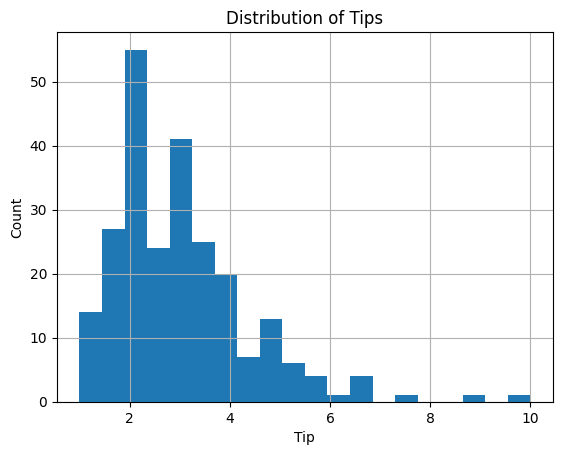

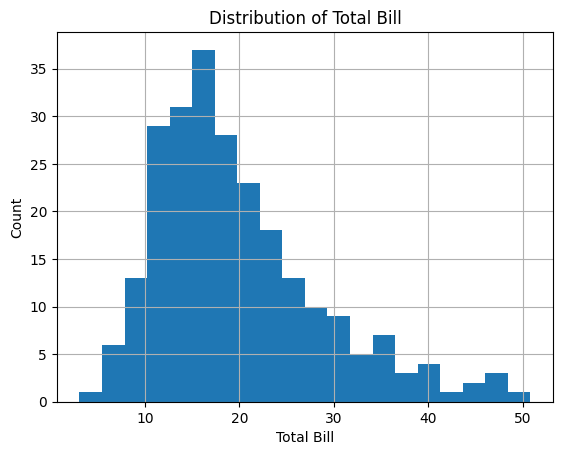

In [3]:
# TODO: histogram of tips
tips['tip'].hist(bins=20)
plt.xlabel('Tip')
plt.ylabel('Count')
plt.title('Distribution of Tips')
plt.show()
# TODO: histogram of  total_bill
tips['total_bill'].hist(bins=20)
plt.xlabel('Total Bill')
plt.ylabel('Count')
plt.title('Distribution of Total Bill')
plt.show()

<details dir="rtl"><summary>פתרון מוסתר</summary>

```python
tips["tip"].hist(bins=20)
plt.xlabel("Tip")
plt.ylabel("Count")
plt.title("Distribution of Tips")
plt.show()

tips["total_bill"].hist(bins=20)
plt.xlabel("Total Bill")
plt.ylabel("Count")
plt.title("Distribution of Total Bill")
plt.show()
```

בדרך כלל נראה שרוב הטיפים והחשבונות נמצאים בערכים נמוכים יחסית, ויש מעט חשבונות/טיפים גבוהים יותר.

</details>

<div dir="rtl" style="text-align:right">

## 3. מעבר מ־EDA לשאלת חיזוי

כעת נשאל שאלה חיזויית:

> האם אפשר לנבא את סכום הטיפ לפי סכום החשבון?

זו בעיית **Supervised Learning**, כי לכל דוגמה יש תשובה ידועה: הטיפ האמיתי.

זו בעיית **Regression**, כי אנחנו מנבאים מספר.

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 3 — Scatter Plot: סכום חשבון מול טיפ

צרו Scatter Plot של:

- ציר X: `total_bill`
- ציר Y: `tip`

שאלות:

1. האם נראה שיש קשר בין החשבון לטיפ?
2. האם הקשר נראה לינארי?
3. האם יש רעש?
4. האם קו ישר יכול להיות מודל סביר?

</div>

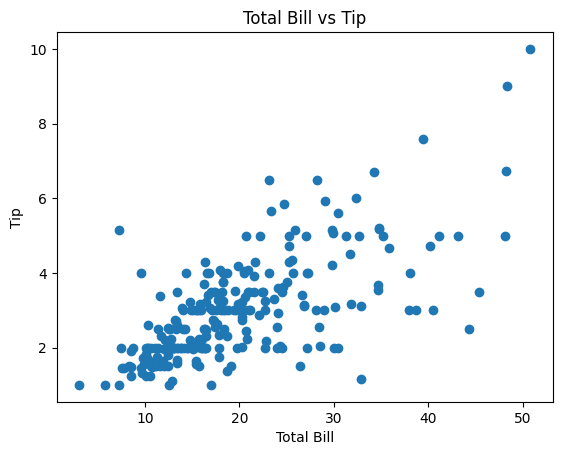

In [4]:
# TODO: create scatter plot of total_bill vs tip
plt.scatter(tips['total_bill'], tips['tip'])
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Total Bill vs Tip')
plt.show()

<details dir="rtl"><summary>פתרון מוסתר</summary>

```python
plt.scatter(tips["total_bill"], tips["tip"])
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("Tip vs Total Bill")
plt.show()
```

פירוש אפשרי:

- ככל שהחשבון גבוה יותר, לרוב הטיפ גבוה יותר.
- הקשר לא מושלם ויש רעש.
- קו ישר יכול להיות התחלה סבירה למודל.

</details>

<div dir="rtl" style="text-align:right">

## 4. מודל רגרסיה לינארית עם פיצ׳ר אחד

נתחיל ממודל פשוט:

`tip = a + b * total_bill`

כאשר:

- `a` הוא intercept.
- `b` הוא slope.
- `total_bill` הוא feature.
- `tip` הוא target.

המטרה של המודל היא למצוא את `a` ו־`b` כך שהתחזיות יהיו קרובות ככל האפשר לערכים האמיתיים.

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 4 — אימון מודל עם פיצ׳ר אחד

אמנו מודל `LinearRegression` שמנבא את `tip` מתוך `total_bill`.

לאחר מכן הדפיסו:

- intercept
- coefficient / slope

</div>

In [5]:
from sklearn.linear_model import LinearRegression

# TODO:
X = tips[['total_bill']]
y = tips['tip']
model_1d = LinearRegression()
model_1d.fit(X, y)

# TODO: print intercept  and coefficient
print("Intercept:", model_1d.intercept_)
print("Coefficient:", model_1d.coef_[0])

Intercept: 0.9202696135546735
Coefficient: 0.10502451738435335


<details dir="rtl"><summary>פתרון מוסתר</summary>

```python
X = tips[["total_bill"]]
y = tips["tip"]

model_1d = LinearRegression()
model_1d.fit(X, y)

print("Intercept:", model_1d.intercept_)
print("Slope:", model_1d.coef_[0])
```

פירוש:

- ה־intercept הוא התחזית כאשר `total_bill = 0`.
- ה־slope אומר בכמה הטיפ החזוי משתנה כאשר החשבון גדל ביחידה אחת.

</details>

<div dir="rtl" style="text-align:right">

## תרגיל 5 — ויזואליזציה של קו הרגרסיה

ציירו את הנקודות המקוריות ואת קו הרגרסיה של המודל.

זו אחת הוויזואליזציות החשובות ביותר בתרגול: היא מראה מה המודל למד.

</div>

   total_bill
0    3.070000
1    3.552222
2    4.034444
3    4.516667
4    4.998889


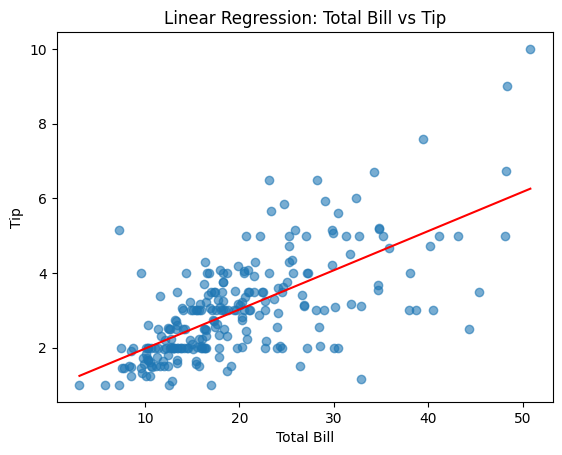

In [7]:
# TODO:
# 1. Create continuous x values between the minimum and maximum of total_bill
x_line = pd.DataFrame({'total_bill': np.linspace(tips['total_bill'].min(), tips['total_bill'].max(), 100)})

print(x_line.head())
# 2. Predict y values for these x values
y_line = model_1d.predict(x_line)
# 3. Plot the scatter plot and the regression line
plt.scatter(tips['total_bill'], tips['tip'], alpha=0.6)
plt.plot(x_line['total_bill'], y_line, color='red')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Linear Regression: Total Bill vs Tip')
plt.show()


<details dir="rtl"><summary>פתרון מוסתר</summary>

```python
x_line = pd.DataFrame({
    "total_bill": np.linspace(tips["total_bill"].min(), tips["total_bill"].max(), 100)
})

y_line = model_1d.predict(x_line)

plt.scatter(tips["total_bill"], tips["tip"], alpha=0.6)
plt.plot(x_line["total_bill"], y_line)
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("Linear Regression Fit: Tip vs Total Bill")
plt.show()
```

הקו מייצג את התחזית של המודל עבור כל ערך אפשרי של סכום החשבון.

</details>

<div dir="rtl" style="text-align:right">

## 5. שגיאות ו־Residuals

עבור כל נקודה:

`residual = y_true - y_pred`

כלומר:

**השארית היא המרחק בין הטיפ האמיתי לבין הטיפ שהמודל חזה.**

Least Squares מחפש את הפרמטרים שמקטינים את סכום ריבועי השגיאות.

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 6 — ציור שאריות על הגרף

בחרו 10 נקודות אקראיות וציירו קווים אנכיים בין הנקודה האמיתית לבין התחזית של המודל.

שאלות:

1. מה מייצג כל קו?
2. איפה המודל טועה יותר?
3. למה לדעתכם משתמשים בריבוע השגיאה?

</div>

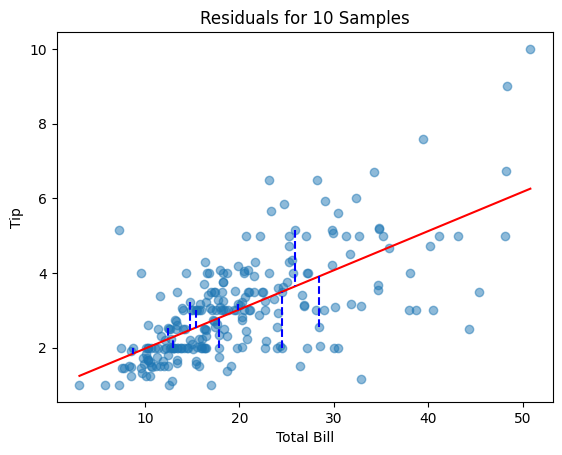

In [11]:
# TODO:
# Plot residual lines for 10 examples
samples = tips.sample(10, random_state=42)
samples

x_samples = samples[['total_bill']]
y_samples_pred = model_1d.predict(x_samples)

plt.scatter(tips['total_bill'], tips['tip'], alpha=0.5)
plt.plot(x_line, y_line, color='red')

for x, y, y_pred in zip(x_samples['total_bill'], samples['tip'], y_samples_pred):
    plt.plot([x, x], [y, y_pred], color='blue', linestyle='--')

plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.title('Residuals for 10 Samples')
plt.show()


<details dir="rtl"><summary>פתרון מוסתר</summary>

```python
sample = tips.sample(10, random_state=1)

X_sample = sample[["total_bill"]]
y_sample = sample["tip"]
y_sample_pred = model_1d.predict(X_sample)

plt.scatter(tips["total_bill"], tips["tip"], alpha=0.35)
plt.plot(x_line["total_bill"], y_line)

for x, y_true, y_hat in zip(sample["total_bill"], y_sample, y_sample_pred):
    plt.plot([x, x], [y_true, y_hat])

plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("Residuals: True Tip vs Predicted Tip")
plt.show()
```

כל קו הוא שגיאת החיזוי עבור דוגמה אחת.

</details>

<div dir="rtl" style="text-align:right">

## 6. Train/Test Split

עד עכשיו אימנו וציירנו על כל הדאטה כדי להבין את הרעיון.

אבל בהערכת מודלים, חשוב לבדוק את המודל על דוגמאות שהוא לא ראה בזמן האימון.

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 7 — חלוקה ל־Train/Test

חלקו את הדאטה ל־80% אימון ו־20% בדיקה.

השתמשו ב־`random_state=42`.

</div>

In [12]:
from sklearn.model_selection import train_test_split

# TODO:
# X_train, X_test, y_train, y_test = train_test_split(...)
X_train, X_test, y_train, y_test = train_test_split(tips[['total_bill']], tips['tip'], test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (195, 1)
X_test shape: (49, 1)
y_train shape: (195,)
y_test shape: (49,)


<details dir="rtl"><summary>פתרון מוסתר</summary>

```python
X = tips[["total_bill"]]
y = tips["tip"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
```

המודל יתאמן על `X_train, y_train` וייבדק על `X_test, y_test`.

</details>

<div dir="rtl" style="text-align:right">

## תרגיל 8 — אימון והערכת מודל פשוט

אמנו `LinearRegression` על סט האימון, חזו על סט הבדיקה, וחשבו:

- MAE
- RMSE
- R²

</div>

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TODO:
# model_simple = ...
# model_simple.fit(...)
# y_pred = ...
# mae = ...
# rmse = ...
# r2 = ...
# print(...)

<details dir="rtl"><summary>פתרון מוסתר</summary>

```python
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

y_pred = model_simple.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
```

פירוש:

- MAE: בכמה דולרים טעינו בממוצע.
- RMSE: דומה ל־MAE, אבל מעניש טעויות גדולות יותר.
- R²: כמה מהשונות ביעד המודל מצליח להסביר.

</details>

<div dir="rtl" style="text-align:right">

## תרגיל 9 — Actual vs Predicted

ציירו גרף שבו:

- ציר X הוא הטיפ האמיתי.
- ציר Y הוא הטיפ החזוי.

הוסיפו קו אלכסוני שמייצג חיזוי מושלם.

</div>

In [ ]:
# TODO: צרו גרף True vs Predicted

<details dir="rtl"><summary>פתרון מוסתר</summary>

```python
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.scatter(y_test, y_pred)
plt.plot([min_val, max_val], [min_val, max_val])
plt.xlabel("True Tip")
plt.ylabel("Predicted Tip")
plt.title("True vs Predicted Tips")
plt.show()
```

אם המודל היה מושלם, כל הנקודות היו יושבות על הקו האלכסוני.

</details>

<div dir="rtl" style="text-align:right">

## תרגיל 10 — בדיקת שאריות

חשבו את השאריות:

`errors = y_test - y_pred`

וצרו:

1. Histogram של השגיאות.
2. Scatter plot של `y_pred` מול השגיאות.

שאלות:

- האם השגיאות סביב 0?
- האם יש תבנית ברורה בשגיאות?
- האם יש outliers?

</div>

In [ ]:
# TODO:
# errors = ...
# histogram
# residuals vs predicted

<details dir="rtl"><summary>פתרון מוסתר</summary>

```python
errors = y_test - y_pred

plt.hist(errors, bins=20)
plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.title("Distribution of Prediction Errors")
plt.show()

plt.scatter(y_pred, errors)
plt.axhline(0)
plt.xlabel("Predicted Tip")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")
plt.show()
```

נרצה לראות שגיאות סביב 0 וללא תבנית חזקה. אם יש תבנית, ייתכן שהמודל פשוט מדי או שחסרים פיצ׳רים.

</details>

<div dir="rtl" style="text-align:right">

## 7. מודל עם יותר פיצ׳רים

עכשיו נוסיף למודל עוד מידע:

- `total_bill`
- `size`
- `day`
- `time`
- `smoker`

אבל חלק מהעמודות הן קטגוריאליות, ולכן צריך להמיר אותן למספרים בעזרת One-Hot Encoding.

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 11 — EDA קטגוריאלי

צרו Bar Plot של ממוצע הטיפ לפי:

1. יום (`day`)
2. זמן הארוחה (`time`)
3. מעשנים/לא מעשנים (`smoker`)

שאלה:

האם לדעתכם כדאי להכניס את המשתנים האלה למודל?

</div>

In [ ]:
# TODO: groupby + bar plots

<details dir="rtl"><summary>פתרון מוסתר</summary>

```python
tips.groupby("day")["tip"].mean().plot(kind="bar")
plt.ylabel("Average Tip")
plt.title("Average Tip by Day")
plt.show()

tips.groupby("time")["tip"].mean().plot(kind="bar")
plt.ylabel("Average Tip")
plt.title("Average Tip by Time")
plt.show()

tips.groupby("smoker")["tip"].mean().plot(kind="bar")
plt.ylabel("Average Tip")
plt.title("Average Tip by Smoker")
plt.show()
```

גם אם רואים הבדלים בין קבוצות, חשוב לזכור: קורלציה אינה בהכרח סיבתיות.

</details>

<div dir="rtl" style="text-align:right">

## תרגיל 12 — One-Hot Encoding ומודל מרובה פיצ׳רים

בנו מודל שמנבא `tip` לפי:

`total_bill`, `size`, `day`, `time`, `smoker`

שלבים:

1. הגדירו `X`.
2. בצעו `pd.get_dummies`.
3. חלקו ל־train/test.
4. אמנו Linear Regression.
5. חשבו MAE, RMSE ו־R².

</div>

In [ ]:
# TODO: מודל עם כמה פיצ'רים

<details dir="rtl"><summary>פתרון מוסתר</summary>

```python
X = tips[["total_bill", "size", "day", "time", "smoker"]]
y = tips["tip"]

X_encoded = pd.get_dummies(X, drop_first=True)

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

model_all = LinearRegression()
model_all.fit(X_train_all, y_train_all)

y_pred_all = model_all.predict(X_test_all)

mae_all = mean_absolute_error(y_test_all, y_pred_all)
rmse_all = np.sqrt(mean_squared_error(y_test_all, y_pred_all))
r2_all = r2_score(y_test_all, y_pred_all)

print("MAE:", mae_all)
print("RMSE:", rmse_all)
print("R2:", r2_all)
```

מודל מרובה פיצ׳רים לא תמיד משפר את התוצאה. צריך לבדוק בפועל לפי מדדי הערכה.

</details>

<div dir="rtl" style="text-align:right">

## 8. Baseline והשוואת מודלים

מודל Machine Learning צריך להיות טוב יותר מפתרון נאיבי.

Baseline פשוט:

> תמיד לחזות את הטיפ הממוצע ב־train.

</div>

<div dir="rtl" style="text-align:right">

## תרגיל 13 — Baseline והשוואה

צרו Baseline שמנבא תמיד את ממוצע הטיפים ב־train.

לאחר מכן צרו טבלת השוואה בין:

1. Baseline
2. Linear Regression עם `total_bill` בלבד
3. Linear Regression עם כל הפיצ׳רים

</div>

In [ ]:
# TODO: baseline + comparison table

<details dir="rtl"><summary>פתרון מוסתר</summary>

```python
baseline_pred = np.full(shape=len(y_test), fill_value=y_train.mean())

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

results = pd.DataFrame({
    "model": ["Baseline", "Linear 1 feature", "Linear all features"],
    "MAE": [baseline_mae, mae, mae_all],
    "RMSE": [baseline_rmse, rmse, rmse_all],
    "R2": [baseline_r2, r2, r2_all]
})

results
```

אפשר להוסיף ויזואליזציה:

```python
results.plot(x="model", y="RMSE", kind="bar", legend=False)
plt.ylabel("RMSE")
plt.title("Model Comparison by RMSE")
plt.show()
```

</details>

<div dir="rtl" style="text-align:right">

## תרגיל 14 — הרחבה: Ridge Regression

נסו מודל Ridge והשוו אותו למודלים הקודמים.

שאלות:

1. האם Ridge שיפר את התוצאה?
2. למה רגולריזציה יכולה לעזור?
3. האם במקרה שלנו יש הרבה פיצ׳רים או מעט?

</div>

In [ ]:
from sklearn.linear_model import Ridge

# TODO: אמנו Ridge והשוו תוצאות

<details dir="rtl"><summary>פתרון מוסתר</summary>

```python
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_all, y_train_all)

y_pred_ridge = ridge.predict(X_test_all)

mae_ridge = mean_absolute_error(y_test_all, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test_all, y_pred_ridge))
r2_ridge = r2_score(y_test_all, y_pred_ridge)

results_extended = pd.DataFrame({
    "model": ["Baseline", "Linear 1 feature", "Linear all features", "Ridge"],
    "MAE": [baseline_mae, mae, mae_all, mae_ridge],
    "RMSE": [baseline_rmse, rmse, rmse_all, rmse_ridge],
    "R2": [baseline_r2, r2, r2_all, r2_ridge]
})

results_extended
```

Ridge מוסיף ענישה על גודל המקדמים. הוא יכול לעזור במיוחד כאשר יש הרבה פיצ׳רים או קשרים חזקים בין פיצ׳רים.

</details>

<div dir="rtl" style="text-align:right">

## שאלות סיכום

ענו בקצרה:

1. מה היה ה־target?
2. מהם ה־features?
3. למה זו בעיית Regression?
4. למה לא מספיק לבדוק את המודל על הדאטה שעליו הוא התאמן?
5. מה ההבדל בין MAE ל־RMSE?
6. מה המשמעות של R²?
7. האם מודל עם יותר פיצ׳רים תמיד טוב יותר?
8. מה אפשר ללמוד מגרף השאריות?

</div>